# Notebook de Optimización: Método de Interpolación Cuadrática

Este cuaderno implementa el método de optimización de Interpolación Cuadrática para encontrar el mínimo de una función unimodal dentro de un intervalo especificado. Además, visualiza la función con el punto óptimo encontrado y la convergencia del error a lo largo de las iteraciones.

## ¿Qué es el Método de Interpolación Cuadrática?

El método de Interpolación Cuadrática es una técnica de optimización que usa tres puntos en el intervalo de búsqueda para ajustar un polinomio cuadrático (parábola). Luego, encuentra el vértice (mínimo o máximo) de esa parábola como aproximación del extremo de la función original.

El algoritmo funciona de la siguiente manera para encontrar un mínimo en el intervalo `[a, b]`:

1. Se seleccionan tres puntos iniciales `x1`, `x2`, `x3` dentro del intervalo `[a, b]`.
2. Se evalúa la función en esos tres puntos: `f(x1)`, `f(x2)`, `f(x3)`.
3. Se ajusta un polinomio cuadrático `p(x) = A*x^2 + B*x + C` a través de esos tres puntos.
4. Se calcula el vértice de la parábola: `x_vértice = -B / (2*A)`.
5. Se evalúa la función en el vértice.
6. Se descarta el punto con mayor valor de función y se reinicia el proceso con los tres mejores puntos.
7. Se repite hasta que converja a una tolerancia especificada.

Una ventaja importante es que la convergencia suele ser más rápida que métodos de bisección o falsa posición, especialmente cerca del mínimo.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import inspect

In [6]:
def funcion_ejemplo(x):
    return x**3 - x**2 -10

# Si quisieras probar con otra función, por ejemplo:
# def funcion_ejemplo(x):
#     return x**4 - 3*x**3 + 2

In [7]:
def vertice_parabola(x1, x2, x3, f1, f2, f3):
    """
    Calcula el vértice de la parábola que pasa por tres puntos
    usando una fórmula numéricamente más estable.
    """
    numerator = (x2 - x1)**2 * (f2 - f3) - (x2 - x3)**2 * (f2 - f1)
    denominator = (x2 - x1) * (f2 - f3) - (x2 - x3) * (f2 - f1)

    if abs(denominator) < 1e-14:
        return None

    xv = x2 - 0.5 * (numerator / denominator)
    return xv


def interpolacion_cuadratica_minimizacion(func, a, b, tol=1e-5, max_iter=100):
    """
    Interpolación cuadrática robusta manteniendo estructura de intervalo.
    """

    if a >= b:
        raise ValueError("El intervalo debe cumplir a < b.")

    # Inicialización (ordenados)
    x1, x2, x3 = a, (a + b) / 2, b
    f1, f2, f3 = func(x1), func(x2), func(x3)

    historial_error = [(0, x3 - x1)]

    for i in range(max_iter):

        xv = vertice_parabola(x1, x2, x3, f1, f2, f3)

        # Si falla la interpolación → fallback a punto medio
        if xv is None or not (x1 < xv < x3):
            xv = (x1 + x3) / 2

        fv = func(xv)

        # 🔑 Mantener puntos ordenados en x
        puntos = sorted([(x1, f1), (x2, f2), (x3, f3), (xv, fv)], key=lambda p: p[0])

        # 🔑 Seleccionar tres puntos consecutivos que rodeen el mínimo
        # Buscar el índice del menor valor
        f_vals = [p[1] for p in puntos]
        idx_min = np.argmin(f_vals)

        # Elegir vecinos alrededor del mínimo
        if idx_min == 0:
            nuevos = puntos[0:3]
        elif idx_min == len(puntos) - 1:
            nuevos = puntos[-3:]
        else:
            nuevos = puntos[idx_min - 1: idx_min + 2]

        (x1, f1), (x2, f2), (x3, f3) = nuevos

        # Asegurar orden
        x1, x2, x3 = sorted([x1, x2, x3])
        f_dict = {x1: func(x1), x2: func(x2), x3: func(x3)}
        f1, f2, f3 = f_dict[x1], f_dict[x2], f_dict[x3]

        intervalo = x3 - x1
        historial_error.append((i + 1, intervalo))

        if intervalo < tol:
            break

    # Mejor punto final
    candidatos = [(x1, f1), (x2, f2), (x3, f3)]
    x_opt, f_opt = min(candidatos, key=lambda p: p[1])

    return x_opt, f_opt, historial_error


def interpolacion_cuadratica_maximizacion(func, a, b, tol=1e-5, max_iter=100):
    """Maximización usando minimización de -f(x)."""
    return interpolacion_cuadratica_minimizacion(
        lambda x: -func(x), a, b, tol, max_iter
    )

In [10]:
# Definir el intervalo inicial de búsqueda
a_intervalo = 0.0
b_intervalo = 2.0
fn= inspect.getsource(funcion_ejemplo).split("return")[-1].strip()
# Definir la tolerancia
tolerancia = 1e-6

print(f"Buscando el mínimo de la función f(x) = {fn} en el intervalo [{a_intervalo}, {b_intervalo}]")
print(f"Con una tolerancia de {tolerancia}\n")

x_min_encontrado, f_min_encontrado, historial_error_min = interpolacion_cuadratica_minimizacion(
    funcion_ejemplo, a_intervalo, b_intervalo, tol=tolerancia
)

print(f"Mínimo encontrado en x = {x_min_encontrado:.6f}")
print(f"Valor de la función en el mínimo = {f_min_encontrado:.6f}")
print(f"Número de iteraciones: {len(historial_error_min) - 1}")
print(f"Error final (tamaño del intervalo) = {historial_error_min[-1][1]:.6e}\n")

# Si quisieras buscar un máximo:
# def funcion_ejemplo_max(x):
#     return -(x - 2)**2 + 5
# x_max_encontrado, f_max_encontrado, historial_error_max = interpolacion_cuadratica_maximizacion(
#     funcion_ejemplo_max, a_intervalo, b_intervalo, tol=tolerancia
# )
# print(f"Máximo encontrado en x = {x_max_encontrado:.6f}")
# print(f"Valor de la función en el máximo = {f_max_encontrado:.6f}")

Buscando el mínimo de la función f(x) = x**3 - x**2 -10 en el intervalo [0.0, 2.0]
Con una tolerancia de 1e-06

Mínimo encontrado en x = 0.500000
Valor de la función en el mínimo = -10.125000
Número de iteraciones: 21
Error final (tamaño del intervalo) = 9.536743e-07



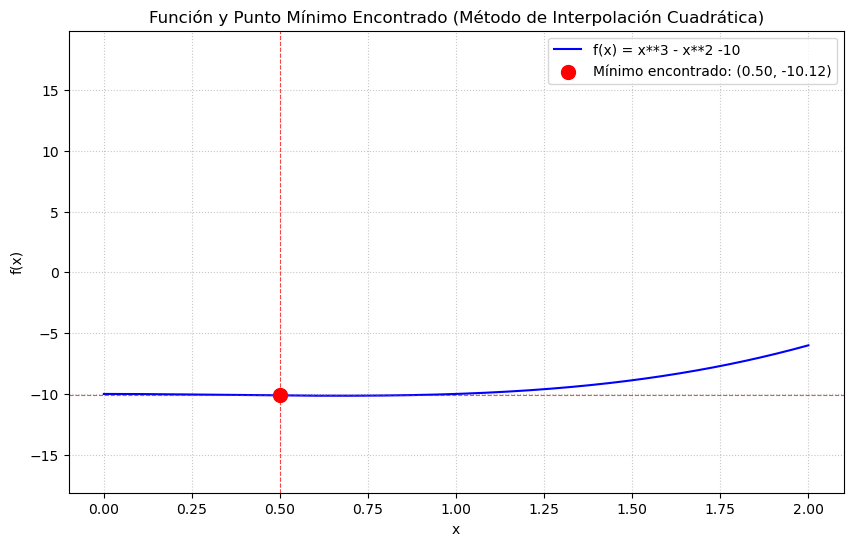

In [11]:
# Generar puntos para graficar la función
x_vals = np.linspace(a_intervalo, b_intervalo, 400)
y_vals = funcion_ejemplo(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label='f(x) = '+fn, color='blue')
plt.scatter(
    x_min_encontrado,
    f_min_encontrado,
    color='red',
    marker='o',
    s=100,
    label=f'Mínimo encontrado: ({x_min_encontrado:.2f}, {f_min_encontrado:.2f})',
    zorder=5
)
plt.axvline(x=x_min_encontrado, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
plt.axhline(y=f_min_encontrado, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
plt.ylim(f_min_encontrado - 8, f_min_encontrado + 30)
plt.title('Función y Punto Mínimo Encontrado (Método de Interpolación Cuadrática)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

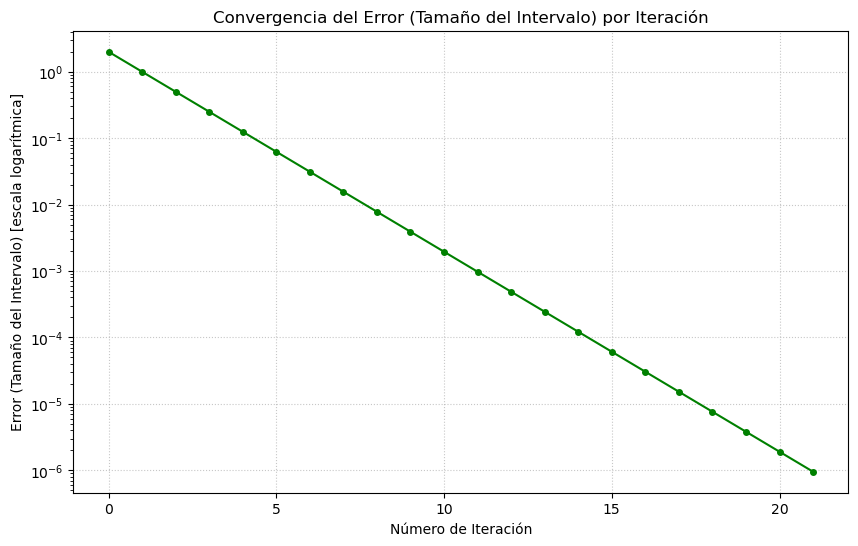

Historial de Error (primeras 10 y últimas 5 iteraciones):
   Iteración  Tamaño del Intervalo
0          0              2.000000
1          1              1.000000
2          2              0.500000
3          3              0.250000
4          4              0.125000
5          5              0.062500
6          6              0.031250
7          7              0.015625
8          8              0.007812
9          9              0.003906
...
    Iteración  Tamaño del Intervalo
17         17          1.525879e-05
18         18          7.629395e-06
19         19          3.814697e-06
20         20          1.907349e-06
21         21          9.536743e-07


In [12]:
# Extraer las iteraciones y los tamaños de intervalo del historial
iteraciones = [item[0] for item in historial_error_min]
errores = [item[1] for item in historial_error_min]

plt.figure(figsize=(10, 6))
plt.plot(iteraciones, errores, marker='o', linestyle='-', color='green', markersize=4)
plt.yscale('log')
plt.title('Convergencia del Error (Tamaño del Intervalo) por Iteración')
plt.xlabel('Número de Iteración')
plt.ylabel('Error (Tamaño del Intervalo) [escala logarítmica]')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

df_error = pd.DataFrame(historial_error_min, columns=['Iteración', 'Tamaño del Intervalo'])
print('Historial de Error (primeras 10 y últimas 5 iteraciones):')
print(df_error.head(10))
print('...')
print(df_error.tail(5))

In [13]:
# Tabla de iteraciones con formato estandar y legible
columnas = [
    'Iteración', 'x_k', 'y_k', 'f(x_k, y_k)',
    'df_dx', 'df_dy', 'h_opt', 'Error_paso', 'Norma_gradiente'
]

filas = []

if 'historial' in globals() and historial:
    n_cols = len(historial[0])
    if n_cols == 9:
        for it, xk, yk, fk, dfx, dfy, h_opt, err, ngrad in historial:
            filas.append([it, xk, yk, fk, dfx, dfy, h_opt, err, ngrad])
    elif n_cols == 4:
        for it, xk, gk, err in historial:
            filas.append([it, xk, np.nan, gk, np.nan, np.nan, np.nan, err, np.nan])
    elif n_cols == 2:
        for it, err in historial:
            filas.append([it, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, err, np.nan])

elif 'historial_raiz' in globals() and historial_raiz:
    for it, xk, gk, err in historial_raiz:
        filas.append([it, xk, np.nan, gk, np.nan, np.nan, np.nan, err, np.nan])

elif 'historial_error_min' in globals() and historial_error_min:
    for it, err in historial_error_min:
        filas.append([it, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, err, np.nan])

elif 'historial_error' in globals() and historial_error:
    for it, err in historial_error:
        filas.append([it, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, err, np.nan])

tabla = pd.DataFrame(filas, columns=columnas)

if tabla.empty:
    print('No se encontraron datos de historial para construir la tabla.')
else:
    tabla_fmt = tabla.copy()
    formato = {
        'x_k': '{:.6f}',
        'y_k': '{:.6f}',
        'f(x_k, y_k)': '{:.6f}',
        'df_dx': '{:.6f}',
        'df_dy': '{:.6f}',
        'h_opt': '{:.6f}',
        'Error_paso': '{:.3e}',
        'Norma_gradiente': '{:.3e}'
    }

    for col, fmt in formato.items():
        tabla_fmt[col] = tabla_fmt[col].map(lambda v: '' if pd.isna(v) else fmt.format(v))

    print('Tabla de iteraciones (valores y error):')
    print(tabla_fmt.to_string(index=False))

Tabla de iteraciones (valores y error):
 Iteración x_k y_k f(x_k, y_k) df_dx df_dy h_opt Error_paso Norma_gradiente
         0                                        2.000e+00                
         1                                        1.000e+00                
         2                                        5.000e-01                
         3                                        2.500e-01                
         4                                        1.250e-01                
         5                                        6.250e-02                
         6                                        3.125e-02                
         7                                        1.562e-02                
         8                                        7.812e-03                
         9                                        3.906e-03                
        10                                        1.953e-03                
        11                                      